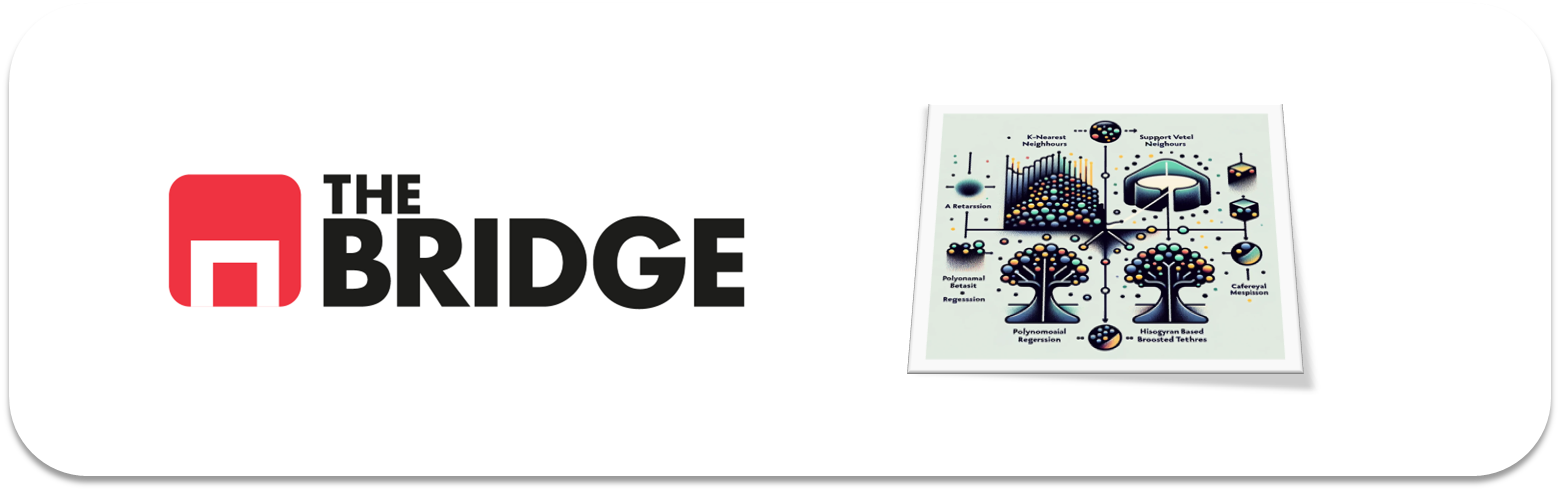

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import bootcampviztools as bt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import ConfusionMatrixDisplay, classification_report, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

#### **Cargamos el dataset y visualizamos los datos**

In [2]:
df = pd.read_csv("./data/wines_dataset.csv", sep="|")
df.head(20)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.210,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.160,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.180,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.260,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.630,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red
5,5.7,0.265,0.28,6.90,0.036,46.0,150.0,0.99299,3.36,0.44,10.8,7,white
6,6.6,0.210,0.31,11.40,0.039,46.0,165.0,0.99795,3.41,0.44,9.8,7,white
7,6.7,0.310,0.30,2.10,0.038,18.0,130.0,0.99280,3.36,0.63,10.6,6,white
8,8.9,0.750,0.14,2.50,0.086,9.0,30.0,0.99824,3.34,0.64,10.5,5,red
9,7.5,0.420,0.20,1.40,0.060,15.0,168.0,0.99440,3.06,0.40,9.4,6,white


In [3]:
df.info() # El dataset no tiene nulos y en principio parecen variables numéricas salvo class, que es categórica

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [5]:
# Realmente existen dos variables categóricas
# Por un lado el tipo de vino (rojo y blanco) y por otro la nota del experto (0-10)

df.groupby("class")["quality"].value_counts()

class  quality
red    5           681
       6           638
       7           199
       4            53
       8            18
       3            10
white  6          2198
       5          1457
       7           880
       8           175
       4           163
       3            20
       9             5
Name: count, dtype: int64

In [6]:
df["class"].value_counts()/len(df["class"])*100 # Reparto de la variable target

class
white    75.388641
red      24.611359
Name: count, dtype: float64

In [7]:
cols_num = [
    'fixed acidity', 
    'volatile acidity',      
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

cols_cat = [
    'class', 
    'quality'
    ]

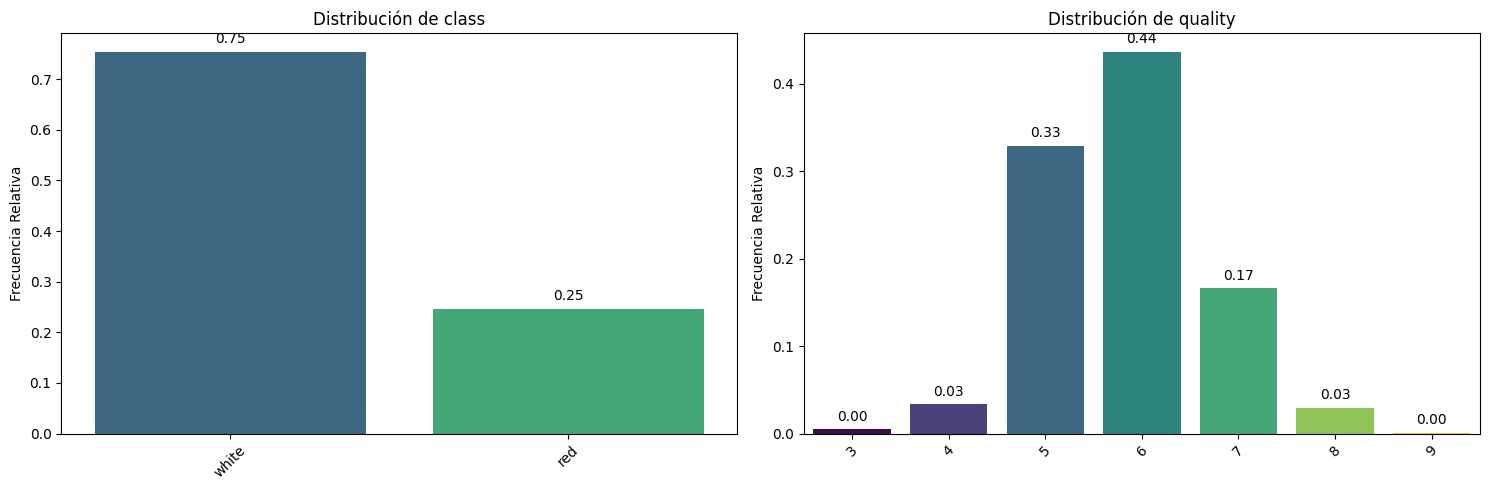

In [8]:
# Distribuciones de las variables categóricas en términos porcentuales
# Hay desbalanceo en la variable target class

bt.pinta_distribucion_categoricas(df, cols_cat, relativa=True, mostrar_valores=True) 

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

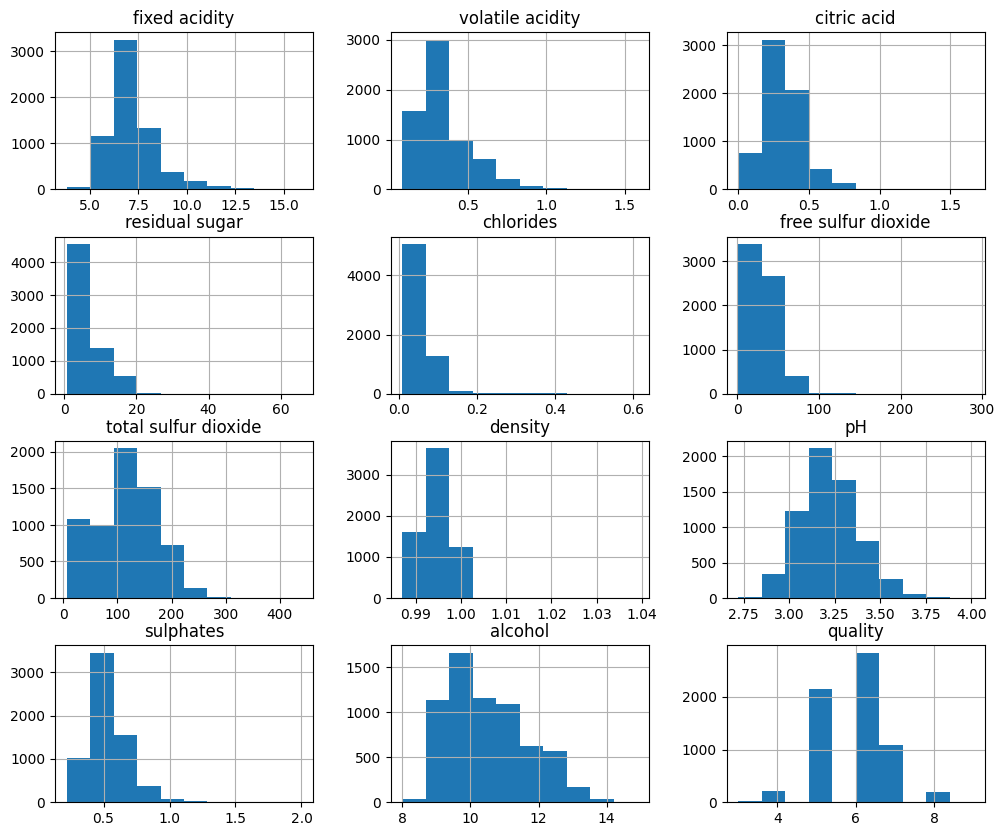

In [9]:
# Distribución en histogramas de las variables numéricas
# Hay variables que tienen una variabilidad muy grande y otras más pequeñas -> escalar va a ser necesario

df.hist(figsize=(12, 10))

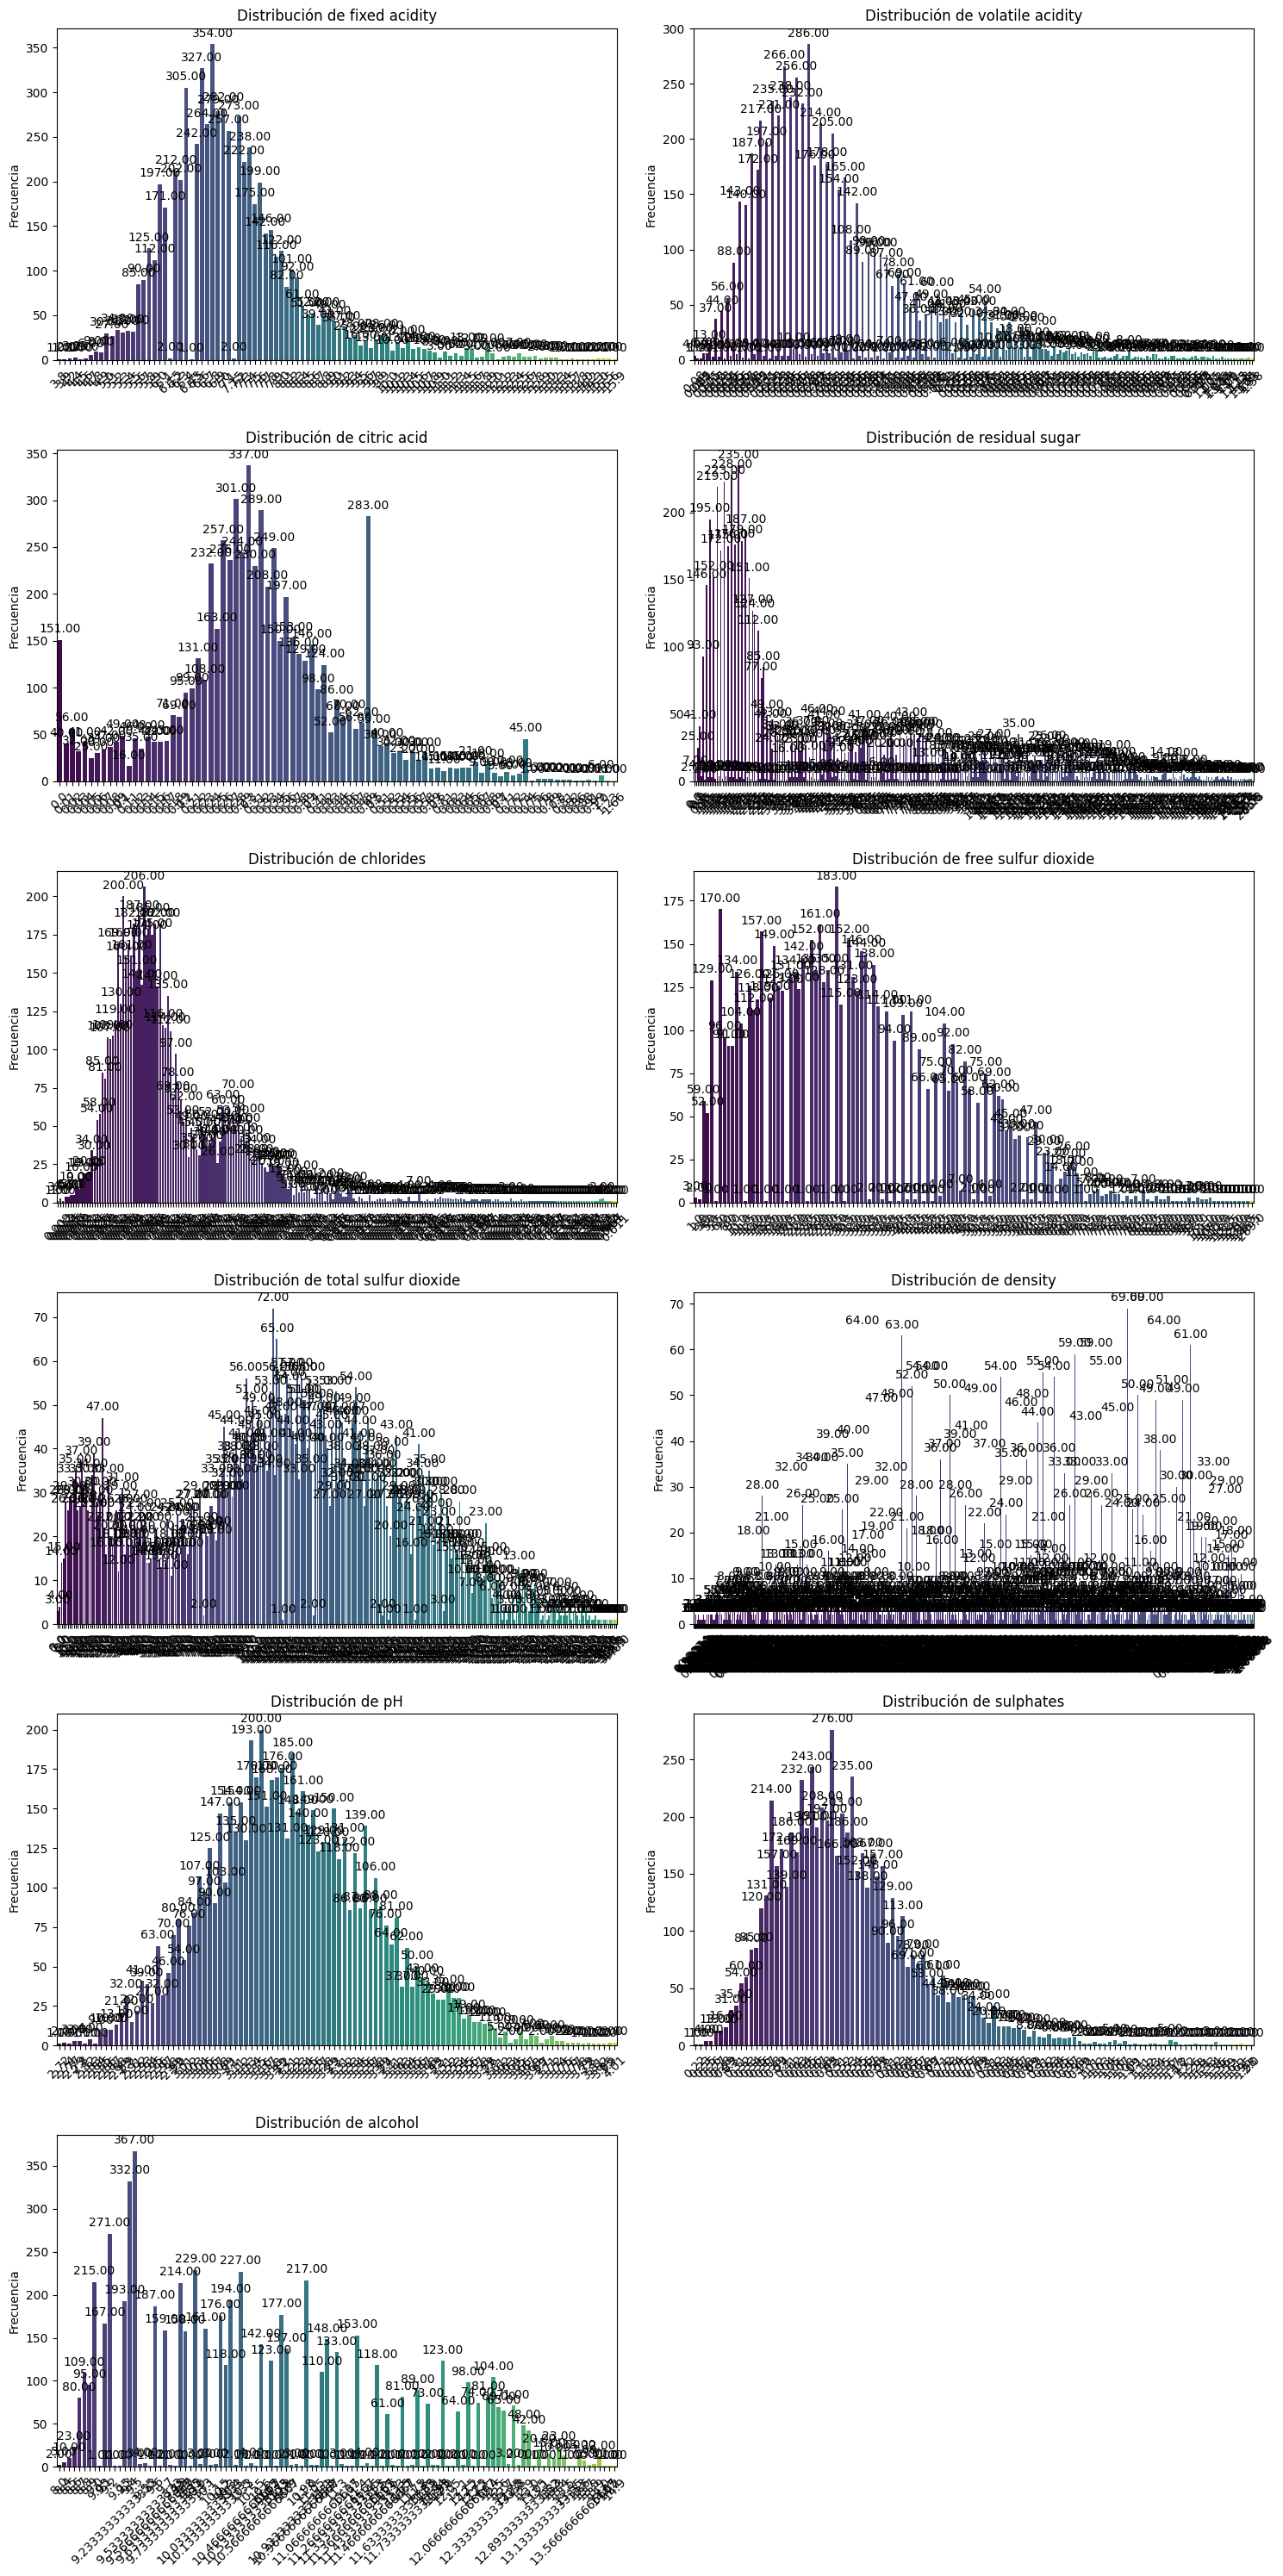

In [10]:
# Distribuciones varibles numéricas en gráfico de barras

bt.pinta_distribucion_categoricas(df, cols_num, relativa=False, mostrar_valores=True)

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [11]:
# Convertimos la variables binaria class en una numérica con dos valores 

df_wines = df.copy()
df_wines["class"] = df_wines["class"].map({"red": 0, "white": 1})

In [12]:
# Establecemos la variables target y el resto de variables
# Hacemos el split de los datos entrenamiento y test

from sklearn.preprocessing import LabelEncoder    

X_clf = df_wines.drop(columns=["quality"])

le_clf = LabelEncoder()                                                      
y_clf = le_clf.fit_transform(df_wines["quality"])  # 3,4,5,6,7,8,9 -> 0,1,2,3,4,5,6


In [13]:
# Hacemos el split estratificando por la variable target aunque no sea un dataset demasiado grande

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, 
    y_clf, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_clf
)

In [14]:
# Hacemos el escalado de train y test por distribución de variables y obligatorio para algunos modelos 

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

In [15]:
X_train_clf.shape

(5197, 12)

In [16]:
X_test_clf.shape

(1300, 12)

In [17]:
# Empezamos con la validación cruzada 

model_names = ["KNN", "Logistic Regression","DecisionTree","Random Forest","XGBoost","LightGBM","CatBoost"]
knn_clf = KNeighborsClassifier(n_neighbors=5)
lr_clf = LogisticRegression(max_iter = 1000, random_state=42)
tree_clf = DecisionTreeClassifier(random_state= 42)
rf_clf = RandomForestClassifier(n_estimators=200, random_state= 42)
xgb_clf = XGBClassifier(random_state = 42)
lgb_clf = LGBMClassifier(random_state= 42, verbose = -100)
cat_clf = CatBoostClassifier(random_state= 42, verbose = False)

model_set = [knn_clf, lr_clf, tree_clf, rf_clf, xgb_clf, lgb_clf, cat_clf]

In [ ]:
# Lanzamos comparativa 

metricas_cv = {}
valores = []
for nombre, modelo in zip(model_names, model_set):
    print(nombre)
    if nombre in ["KNN", "Logistic Regression"]:
        metricas_cv[nombre] = cross_val_score(modelo, X_train_clf_scaled, y_train_clf, cv=3, scoring="balanced_accuracy")
    else:
        metricas_cv[nombre] = cross_val_score(modelo, X_train_clf, y_train_clf, cv=3, scoring="balanced_accuracy")
        valores.append(np.mean(metricas_cv[nombre]))
ganador = list(metricas_cv.keys())[np.argmax(valores)]

KNN
Logistic Regression
DecisionTree
Random Forest
XGBoost
LightGBM
CatBoost


In [ ]:
for model_name, valores in metricas_cv.items():
    print(f"Model <{model_name}>, Accuracy_CV: {np.mean(valores)}")
print(f"El ganador es {ganador}")

Model <KNN>, Accuracy_CV: 0.27306936481681376
Model <Logistic Regression>, Accuracy_CV: 0.2341394236832374
Model <DecisionTree>, Accuracy_CV: 0.35665880166696073
Model <Random Forest>, Accuracy_CV: 0.33909903783914164
Model <XGBoost>, Accuracy_CV: 0.343215628996143
Model <LightGBM>, Accuracy_CV: 0.34548017672231435
Model <CatBoost>, Accuracy_CV: 0.3426798922808485
El ganador es KNN


#### **Optimización de modelos**

In [21]:
metricas_optimizadas = {}

##### Optimización de Árboles de decisión

In [22]:
tree_clf = DecisionTreeClassifier()

param_grid = {
    "max_depth": [1,2,4,8,None],
    "min_samples_leaf": [1,5,10,20],
    "max_features": ["sqrt","log2", None]
    }

tree_grid = GridSearchCV(estimator=tree_clf, 
                         cv = 3,
                         param_grid= param_grid, 
                         scoring = "balanced_accuracy")

tree_grid.fit(X_train_clf_scaled,y_train_clf)
print("Recall optimizada para Árboles de Decisión:", tree_grid.best_score_)
print("Mejores parámetros encontrados:", tree_grid.best_params_)
metricas_optimizadas["DecisionTree"] = tree_grid.best_score_

Recall optimizada para Árboles de Decisión: 0.3446517364249004
Mejores parámetros encontrados: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1}


##### Optimización de CatBoost

In [23]:
cat_clf = CatBoostClassifier(
    verbose = False, 
    auto_class_weights='Balanced',
    random_state=42
    )

param_grid_cat = {
    'depth': [4, 6, 8], 
    'learning_rate': [0.01, 0.05, 0.1], 
    'colsample_bylevel': [0.5, 0.8, 1],
    'iterations': [250, 500, 1000],
    "border_count": [128, 254],
    'l2_leaf_reg': [1, 3, 5, 7]
    }

cat_grid = RandomizedSearchCV(cat_clf, 
                        cv = 10,
                        n_iter = 20,
                        param_distributions= param_grid_cat, 
                        scoring = "balanced_accuracy",
                        n_jobs=-1,
                        random_state=42
                        )


cat_grid.fit(X_train_clf_scaled,y_train_clf)
print("Mejor Recall encontrada:", cat_grid.best_score_)
print("Mejores parámetros encontrados:", cat_grid.best_params_)
metricas_optimizadas["CatBoost"] = cat_grid.best_score_

c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(


Mejor Recall encontrada: 0.4414246453539291
Mejores parámetros encontrados: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 4, 'colsample_bylevel': 0.8, 'border_count': 254}


#### Optimización del modelo KNN

In [31]:
from sklearn.pipeline import Pipeline

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'knn__weights': ['uniform', 'distance'],     
    'knn__metric': ['euclidean', 'manhattan']
    }

knn_grid = GridSearchCV(estimator=knn_pipe,
    param_grid=param_grid_knn,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1
)

knn_grid.fit(X_train_clf,y_train_clf)
print("Mejor Recall encontrada:", knn_grid.best_score_)
print("Mejores parámetros encontrados:", knn_grid.best_params_)
metricas_optimizadas["KNN"] = knn_grid.best_score_

c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Mejor Recall encontrada: 0.37208071018009503
Mejores parámetros encontrados: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}


#### Optimización de Random Forest

In [34]:
rf_clf = RandomForestClassifier()

params_grid = {
    "n_estimators": [100,200,400],
    "max_depth": [2,4,10],
    "min_samples_leaf": [10,20,40],
    "max_features": ["sqrt","log2",None],
    "max_samples": [0.3,0.6,1]
}

rf_grid = GridSearchCV(rf_clf,
                       param_grid= params_grid,
                       cv = 3,
                       scoring = "balanced_accuracy",
                       n_jobs = -1)

rf_grid.fit(X_train_clf_scaled,y_train_clf)
print("Mejor Recall encontrada:", rf_grid.best_score_)
print("Mejores parámetros encontrados:", rf_grid.best_params_)
metricas_optimizadas["Random Forest"] = rf_grid.best_score_

Mejor Recall encontrada: 0.24070747256116376
Mejores parámetros encontrados: {'max_depth': 10, 'max_features': None, 'max_samples': 0.6, 'min_samples_leaf': 10, 'n_estimators': 400}


#### Optimización de XGBoost

In [33]:
xgb_clf = XGBClassifier()

param_grid = {'max_depth': [3, 6, 10, 15],
          'learning_rate': [0.1, 0.2, 0.3, 0.4],
          'subsample': np.arange(0.5, 1.0, 0.1),
          'colsample_bytree': np.arange(0.5, 1.0, 0.1),
          'colsample_bylevel': np.arange(0.5, 1.0, 0.1),
          'n_estimators': [100, 250, 500, 750],
          }

xgb_grid = RandomizedSearchCV(xgb_clf, 
                               cv = 3,
                               n_iter = 20,
                               param_distributions= param_grid, 
                               scoring = "balanced_accuracy")


xgb_grid.fit(X_train_clf_scaled,y_train_clf)
print("XGB best_score:", xgb_grid.best_score_)
metricas_optimizadas["XGBoost"] = xgb_grid.best_score_

XGB best_score: 0.3570773278340041


#### Optimización de LightBoost

In [35]:
lgb_clf = LGBMClassifier(verbose = -100)

param_grid= {'max_depth': [3, 6, 12],
          'learning_rate': [0.1, 0.2, 0.3, 0.4],
          'bagging_fraction': [0.3,0.6,1],
          'feature_fraction': [0.5,1],
          'n_estimators': [100, 250, 500, 750],
          'max_bins': [125,250]
          }

lgb_grid = RandomizedSearchCV(lgb_clf, 
                               cv = 3,
                               n_iter = 20,
                               param_distributions= param_grid, 
                               scoring = "balanced_accuracy")


lgb_grid.fit(X_train_clf_scaled,y_train_clf)
print("LGB best_score:", lgb_grid.best_score_)
metricas_optimizadas["LightGBM"] = lgb_grid.best_score_

LGB best_score: 0.346615653832624


### **Evaluación del modelo ganador: CatBoost**

In [36]:
mejor_modelo = cat_grid.best_estimator_
y_pred_clf_scaled = mejor_modelo.predict(X_test_clf_scaled)
print("Informe de clasificación Modelo CastBoost")
print(classification_report(y_test_clf, y_pred_clf_scaled))

Informe de clasificación Modelo CastBoost
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.15      0.51      0.23        43
           2       0.60      0.60      0.60       428
           3       0.62      0.31      0.42       567
           4       0.38      0.47      0.42       216
           5       0.14      0.54      0.23        39
           6       0.00      0.00      0.00         1

    accuracy                           0.45      1300
   macro avg       0.27      0.35      0.27      1300
weighted avg       0.54      0.45      0.46      1300



c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to cont

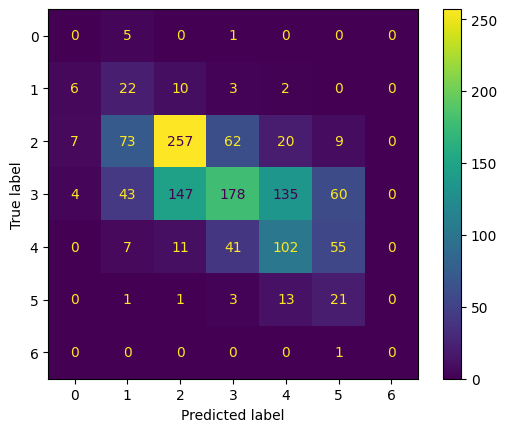

In [37]:
ConfusionMatrixDisplay.from_predictions(y_test_clf, y_pred_clf_scaled, cmap='viridis')

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [39]:
X_reg = df_wines.drop(columns=["alcohol"])
y_reg = df_wines["alcohol"]

In [40]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [41]:
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [38]:
model_names_rg = ["Regresion Lineal","DecisionTree","Random Forest","XGBoost","LightGBM","CatBoost"]
lr_rg = LinearRegression()
tree_rg = DecisionTreeRegressor(random_state= 42)
rf_rg = RandomForestRegressor(random_state= 42)
xgb_rg = XGBRegressor(random_state = 42)
lgb_rg = LGBMRegressor(random_state= 42, verbose = -100)
cat_rg = CatBoostRegressor(random_state= 42, verbose = False)

model_set_rg = [lr_rg, tree_rg, rf_rg, xgb_rg, lgb_rg, cat_rg]

In [43]:
metricas_cv_rg = {}
valores_rg = []
for nombre,modelo in zip(model_names_rg, model_set_rg):
    print(modelo)
    if nombre == "Regresion Lineal":
        metricas_cv_rg[nombre] = cross_val_score(modelo, X_train_reg_scaled, y_train_reg, cv = 3, scoring = "neg_mean_squared_error")
    else:
        metricas_cv_rg[nombre] = cross_val_score(modelo, X_train_reg_scaled, y_train_reg, cv = 3, scoring = "neg_mean_squared_error")
        valores_rg.append(np.mean(metricas_cv_rg[nombre]))
ganador = list(metricas_cv_rg.keys())[np.argmax(valores_rg)]

LinearRegression()
DecisionTreeRegressor(random_state=42)
RandomForestRegressor(random_state=42)
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)
LGBMRegressor(random_state=42, verbose=-100)


In [ ]:
for model_name, valores in metricas_cv_rg.items():
    print(f"Model <{model_name}>, RMSE_CV: {np.sqrt(-np.mean(valores_rg))}")
print(f"El ganador es {ganador}")

# Me dan todas las cifras igual y no sé por qué... :-(

Model <Regresion Lineal>, RMSE_CV: 0.4408916182658325
Model <DecisionTree>, RMSE_CV: 0.4408916182658325
Model <Random Forest>, RMSE_CV: 0.4408916182658325
Model <XGBoost>, RMSE_CV: 0.4408916182658325
Model <LightGBM>, RMSE_CV: 0.4408916182658325
Model <CatBoost>, RMSE_CV: 0.4408916182658325
El ganador es LightGBM


In [51]:
# Optimizamos LightGBM

lgb_clf = LGBMRegressor(verbose = -100)

param_grid= {'max_depth': [3, 6, 12],
          'learning_rate': [0.1, 0.2, 0.3, 0.4],
          'bagging_fraction': [0.3,0.6,1],
          'feature_fraction': [0.5,1],
          'n_estimators': [100, 250, 500, 750],
          'max_bins': [125,250]
          }

lgb_grid = RandomizedSearchCV(lgb_clf, 
                               cv = 3,
                               n_iter = 20,
                               param_distributions= param_grid, 
                               scoring = "neg_mean_squared_error")


lgb_grid.fit(X_train_reg_scaled, y_train_reg)
print("LGB best_score:", np.sqrt(-lgb_grid.best_score_))
metricas_optimizadas["LightGBM"] = np.sqrt(-lgb_grid.best_score_)

LGB best_score: 0.3731243482004579


In [52]:
### CatBoost

cat_clf = CatBoostRegressor(verbose = False)

param_grid= {'depth': [3, 6, 12],
          'learning_rate': [0.1, 0.2, 0.3, 0.4],
          #'bagging_fraction': [0.3,0.6,1], No hay hiperparámetro equivalente
          'colsample_bylevel': [0.5,1],
          'iterations': [100, 250, 500, 750],
          "border_count": [125,250]
          }


cat_grid = RandomizedSearchCV(cat_clf, 
                               cv = 3,
                               n_iter = 3,
                               param_distributions= param_grid, 
                               scoring = "neg_mean_squared_error")


cat_grid.fit(X_train_reg_scaled, y_train_reg)
print("CatBoost best_score:", np.sqrt(-cat_grid.best_score_))
metricas_optimizadas["CatBoost"] = np.sqrt(-cat_grid.best_score_)

CatBoost best_score: 0.37880995782573457


In [ ]:
### XGBoost

xgb_clf = XGBRegressor()

param_grid = {'max_depth': [3, 6, 10, 15],
          'learning_rate': [0.2, 0.6, 0.9],
          'subsample': np.arange(0.5, 1.0, 0.1),
          'colsample_bytree': np.arange(0.5, 1.0, 0.1),
          'colsample_bylevel': np.arange(0.5, 1.0, 0.1),
          'n_estimators': [100, 250, 500, 750],
          }

xgb_grid = RandomizedSearchCV(xgb_clf, 
                               cv = 3,
                               n_iter = 20,
                               param_distributions= param_grid, 
                               scoring = "neg_mean_squared_error")


xgb_grid.fit(X_train_reg_scaled, y_train_reg)
print("XGB best_score:", np.sqrt(-xgb_grid.best_score_))
metricas_optimizadas["XGBoost"] = np.sqrt(-xgb_grid.best_score_)

XGB best_score: 0.3942626637332197


In [53]:
### DecisionTrees

tree_clf = DecisionTreeRegressor()

param_grid = {
    "max_depth": [1,2,4,8,None],
    "min_samples_leaf": [1,5,10,20],
    "max_features": ["sqrt","log2", None]
}

tree_grid = RandomizedSearchCV(tree_clf, 
                               cv = 3,
                               n_iter = 20,
                               param_distributions= param_grid, 
                               scoring = "neg_mean_squared_error")

tree_grid.fit(X_train_reg_scaled, y_train_reg)
print("Tree best_score:", np.sqrt(-tree_grid.best_score_))
metricas_optimizadas["Tree"] = np.sqrt(-tree_grid.best_score_)

Tree best_score: 0.5603160298200487


In [54]:
### Linear Regresion
from sklearn.linear_model import ElasticNet

param_grid = {
    "alpha": [0.1, 1, 10, 100],
    "l1_ratio": [0.2,0.4,0.6,1]

} 
model = ElasticNet()
lr_grid = RandomizedSearchCV( model,
                             cv = 3, 
                             n_iter = 20,
                             param_distributions= param_grid,
                             scoring= "neg_mean_squared_error"
)

lr_grid.fit(X_train_reg, y_train_reg)
print("LR best_score:", np.sqrt(-lr_grid.best_score_))
metricas_optimizadas["Linear Regresion"] = np.sqrt(-lr_grid.best_score_)

c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


LR best_score: 0.9526831892853671


In [59]:
best_reg = lr_grid.best_estimator_
y_pred_reg = best_reg.predict(X_test_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
mape_test = mean_absolute_percentage_error(y_test_reg, y_pred_reg)

print(f"MAE:  {mae:.4f} grados")
print(f"RMSE: {rmse:.4f} grados")
print(f"MAPE: {mape_test * 100:.2f}%")

MAE:  0.7716 grados
RMSE: 0.9628 grados
MAPE: 7.30%


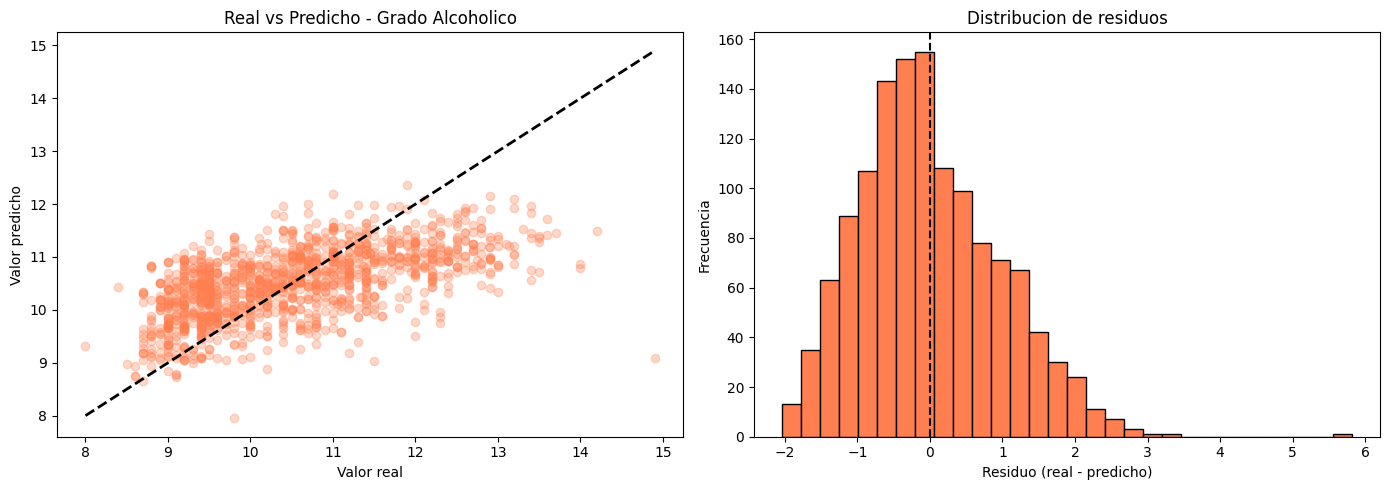

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.3, color="coral")
axes[0].plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    "k--", lw=2,
)
axes[0].set_xlabel("Valor real")
axes[0].set_ylabel("Valor predicho")
axes[0].set_title("Real vs Predicho - Grado Alcoholico")

residuos = y_test_reg - y_pred_reg
axes[1].hist(residuos, bins=30, color="coral", edgecolor="black")
axes[1].axvline(x=0, color="black", linestyle="--")
axes[1].set_xlabel("Residuo (real - predicho)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribucion de residuos")
plt.tight_layout()
plt.show()

In [64]:
# Feature importance

feat_imp_reg = pd.Series(best_reg.feature_importances_, index=X_train_reg.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
feat_imp_reg.plot(kind="barh", ax=ax, color="coral")
ax.set_title("Importancia de caracteristicas - Regresion")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()


AttributeError: 'ElasticNet' object has no attribute 'feature_importances_'